# Computer Vision 1: Assignment 2

Task 2

Group Number 43

Marek Drwal

01.12.2025

## setup

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

## defs

In [2]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    plt.show()

In [3]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [4]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [5]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [ ]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## the woman

In [7]:
pth = 'woman.png'

### imgs

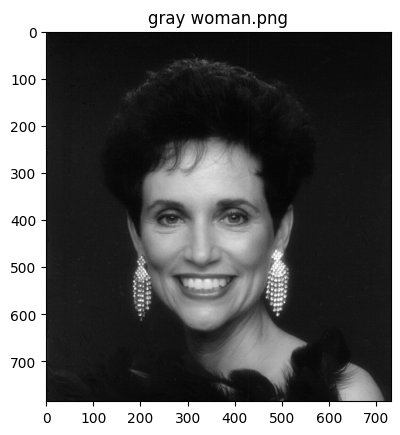

In [8]:
woman = load_display_img(pth, is_gray=True)

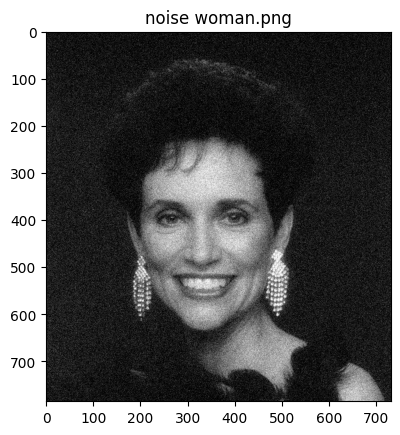

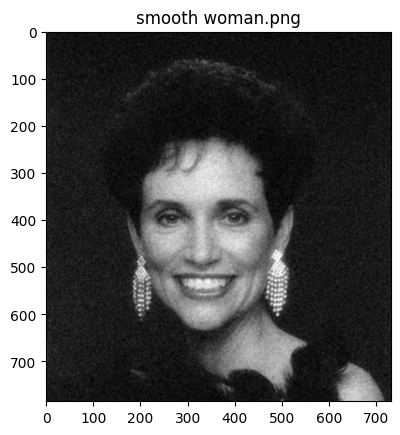

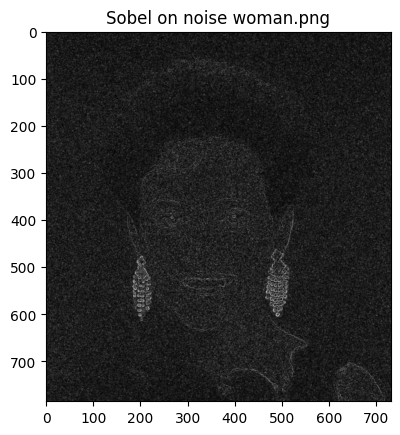

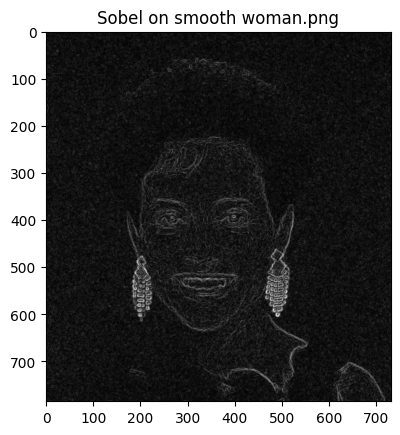

In [9]:
N, S, FN, FS = augment_img(woman, pth)

### histograms

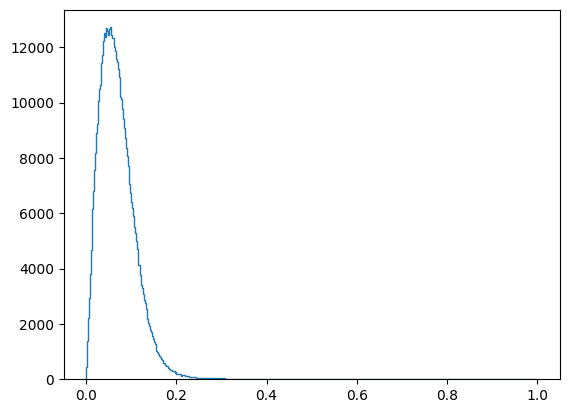

In [10]:
hist_N = plot_img_hist(FN)

In [11]:
tn = 0.17

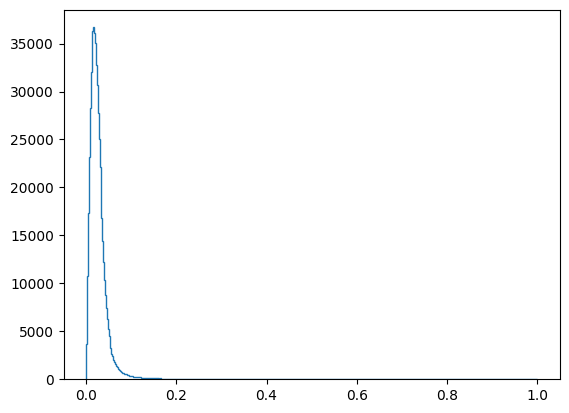

In [12]:
hist_S = plot_img_hist(FS)

In [13]:
ts = 0.075

### binary masks

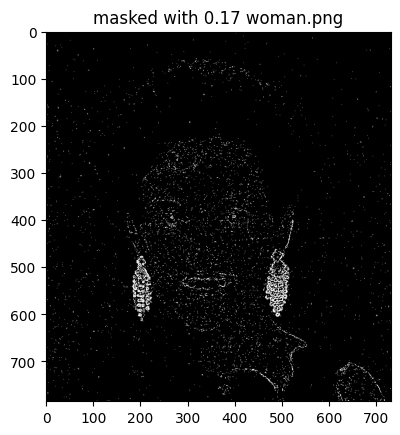

In [ ]:
masked_FN = binary_mask(FN, tn, pth, 'FN')

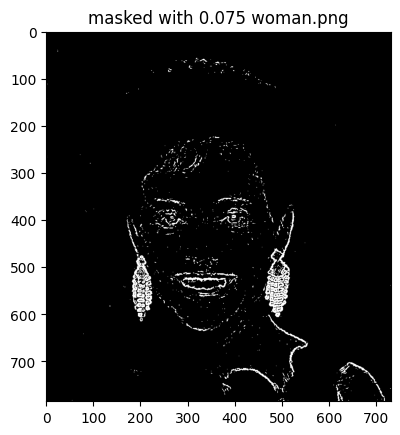

In [ ]:
masked_FS = binary_mask(FS, ts, pth, 'FS')

 Why is edge detection improved by applying smoothing?
 Smoothing removes noise, which has great impact on gradients

## TRUDI

### 022

In [16]:
pth = '0222.jpg'

#### imgs

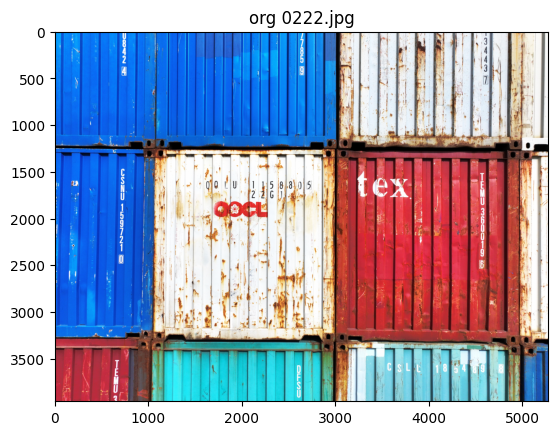

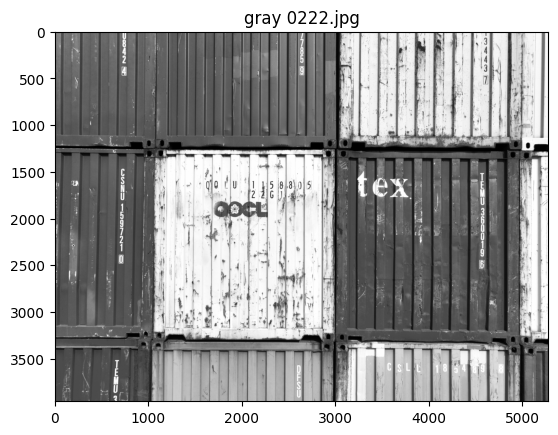

In [17]:
img = load_display_img(pth)

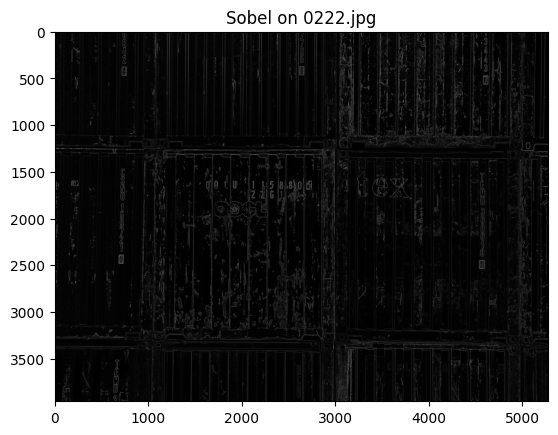

In [18]:
FS = augment_img(img, pth, noise_smooth=False)

#### histograms

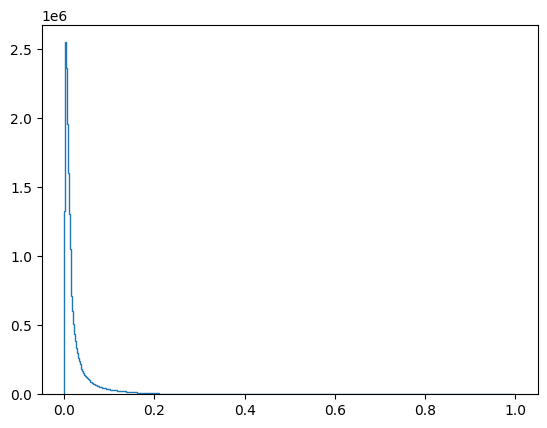

In [19]:
hist_S = plot_img_hist(FS)

In [20]:
ts = 0.075

#### binary masks

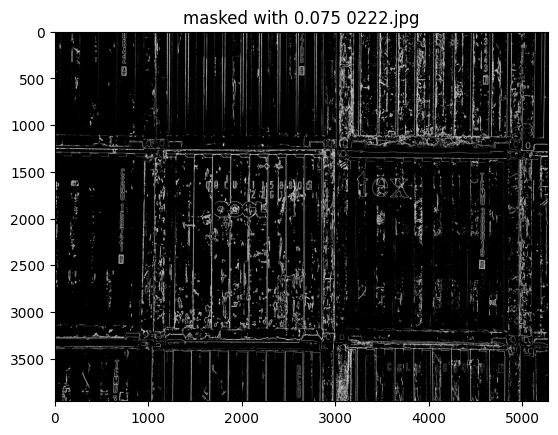

In [21]:
masked_FS = binary_mask(FS, ts, pth)

### DJI

In [22]:
pth = 'DJI_0409.jpg'

#### imgs

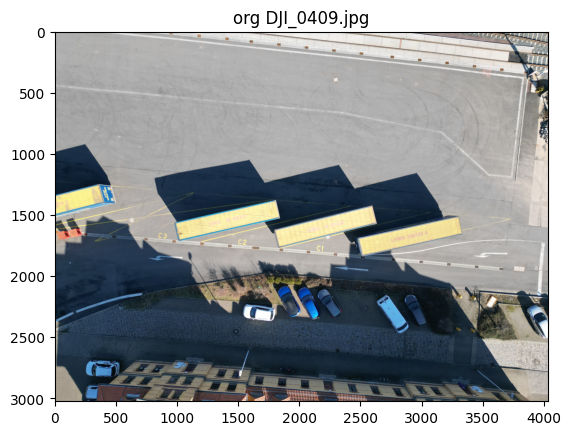

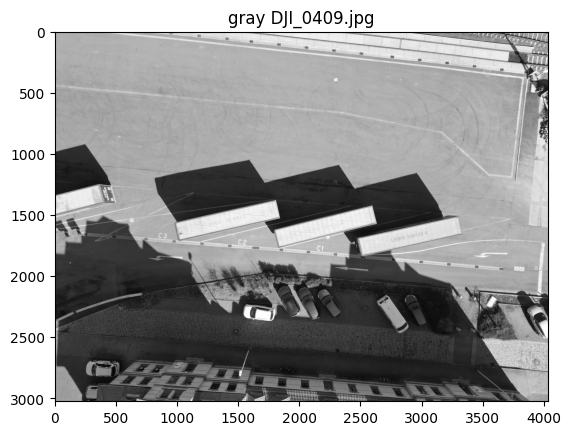

In [23]:
img = load_display_img(pth)

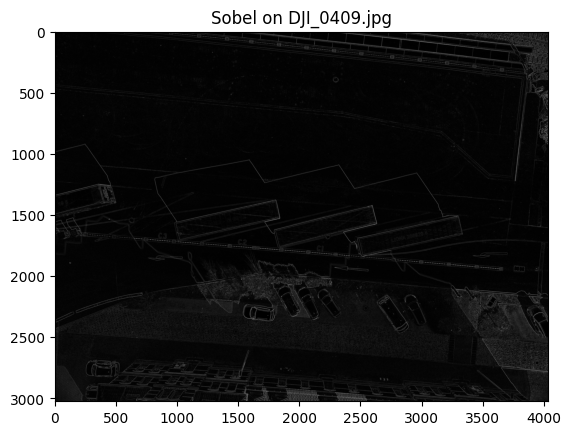

In [24]:
FS = augment_img(img, pth, noise_smooth=False)

#### histograms

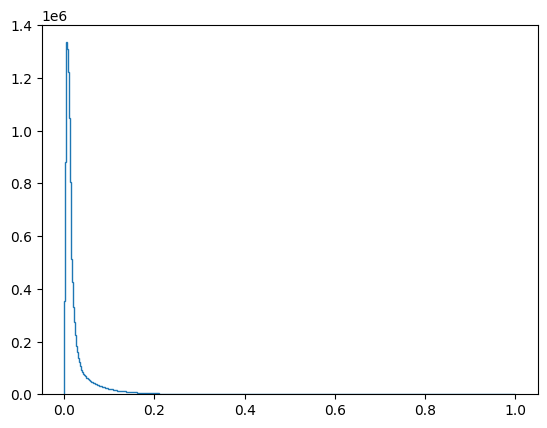

In [25]:
hist_S = plot_img_hist(FS)

In [26]:
ts = 0.075

#### binary masks

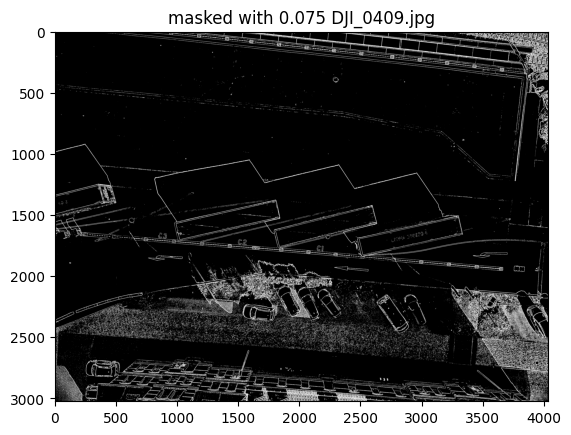

In [27]:
masked_FS = binary_mask(FS, ts, pth)

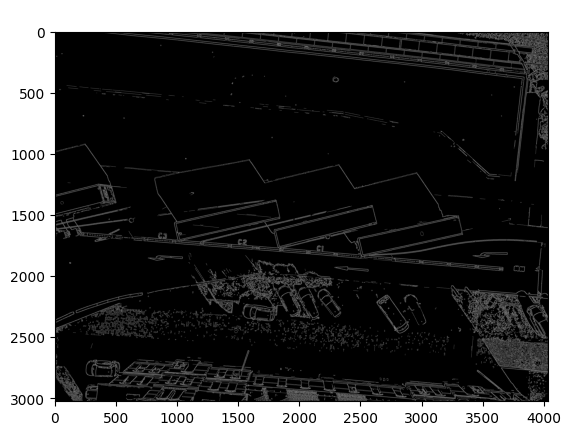

In [28]:
show_img(ski.feature.canny(FS))

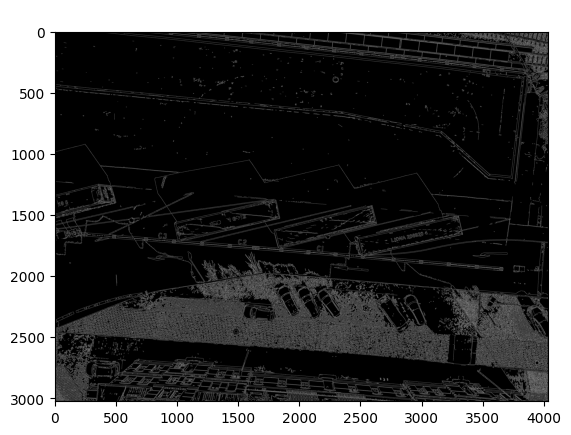

In [29]:
show_img(ski.feature.canny(img))